# Email spam classification with BERT and GPT-2(V2)

## 1.Download data
Download the data from Kaggle and unzip it.

The folder structure is set up for Google Colab; adjust it as needed for your environment.

In [1]:
import os

# Local path
filepath = "/content/emails-for-spam-or-ham-classification-trec-2007.zip"

# File original URL
url = "https://www.kaggle.com/api/v1/datasets/download/bayes2003/emails-for-spam-or-ham-classification-trec-2007"

# Skip download & unzip if file existed
if os.path.exists(filepath):
    print(f"{filepath} already existed, skipping downloading.")
else:
    print(f"{filepath} not found, download and pre-process.")
    !curl -L -o {filepath} {url}
    !unzip {filepath}



/content/emails-for-spam-or-ham-classification-trec-2007.zip not found, download and pre-process.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  482M  100  482M    0     0  20.0M      0  0:00:24  0:00:24 --:--:-- 21.7M
Archive:  /content/emails-for-spam-or-ham-classification-trec-2007.zip
  inflating: email_origin.csv        
  inflating: email_text.csv          
  inflating: trec07p.tgz             


## 2.Install missing python libs

In [2]:
import importlib.util
import sys
import subprocess

# Install all the libraries, skip it if already installed
def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"{package_name} is already installed.")

install_if_missing("matplotlib", "matplotlib")
install_if_missing("torch", "torch")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("nltk", "nltk")
install_if_missing("torchviz", "torchviz")
install_if_missing("datasets", "datasets")
install_if_missing("pandas", "pandas")
install_if_missing("transformers", "transformers")
install_if_missing("sentence-transformers", "sentence_transformers")

matplotlib is already installed.
torch is already installed.
scikit-learn is already installed.
nltk is already installed.
Installing torchviz...
datasets is already installed.
pandas is already installed.
transformers is already installed.
sentence-transformers is already installed.


## 3.Import libs and functions

In [3]:
# Import all the libraries and related functions

import os
import glob
import re
import pandas as pd
import re
import string
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR

from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, precision_recall_fscore_support,confusion_matrix

from sklearn.model_selection import train_test_split

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from transformers import BertModel, BertTokenizer
from transformers import GPT2Tokenizer, GPT2Model
from transformers import GPT2ForSequenceClassification
from transformers import Trainer
from transformers import TrainingArguments

from sentence_transformers import SentenceTransformer

## 4.Download common words

In [4]:
# Download related common words which will be used in the pre-processing step

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 5.Read email dataset

In [5]:
# Read csv file to memory
df = pd.read_csv(r'email_text.csv')

# Add new column 'category' based on 'label' to show spam and ham information
df['category'] = df['label'].apply(lambda x: 'spam' if x == 1 else 'ham')

# Show samples
df.head()

,label,text,category
0,1,do you feel the pressure to perform and not ri...,spam
1,0,hi i've just updated from the gulus and i chec...,ham
2,1,mega authenticv i a g r a discount pricec i a ...,spam
3,1,hey billy it was really fun going out the othe...,spam
4,1,system of the home it will have the capabiliti...,spam


## 6.Show dataset information and percentage of ham and spam

Given the relatively small imbalance between ham and spam, we will not apply dataset balancing

In [6]:
# Show data frame basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53668 entries, 0 to 53667
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     53668 non-null  int64 
 1   text      53668 non-null  object
 2   category  53668 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [7]:
df.category.value_counts(normalize=True)

,proportion
category,
spam,0.557558
ham,0.442442


In [8]:
df.category.value_counts()

,count
category,
spam,29923
ham,23745


## 7.Define cleaner function, then pre-processing

In [9]:
def text_cleaner(text):

    # Convert to lower case
    text = text.lower()

    # Replace the abbreviation with the full form
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'m", " am", text)

    # Removes all punctuation and special symbols from text
    text = re.sub(r'[^\w\s]', '', text)

    # Only english stop words will be processed
    stop_words = set(stopwords.words('english'))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove all stop words from dataset
    filtered_text = [word for word in tokens if word.lower() not in stop_words]

    # Lemmatizer
    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_text]

    cleaned_text = ' '.join(lemmatized_text)

    # Processed dataset ready for training
    return cleaned_text

In [10]:
# Pre processing dataset
df['cleaned_text'] = df['text'].apply(text_cleaner)
df.head()

,label,text,category,cleaned_text
0,1,do you feel the pressure to perform and not ri...,spam,feel pressure perform rising occasion try v ia...
1,0,hi i've just updated from the gulus and i chec...,ham,hi updated gulu check mirror seems little typo...
2,1,mega authenticv i a g r a discount pricec i a ...,spam,mega authenticv g r discount pricec l discount...
3,1,hey billy it was really fun going out the othe...,spam,hey billy really fun going night talking said ...
4,1,system of the home it will have the capabiliti...,spam,system home capability linked far know within ...


## 8.Split dataset

In [11]:
# split to 70%-15%-15%(Training-Validate-Test)

texts = df["cleaned_text"].tolist()
labels = df["label"].tolist()

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.1764706,  # 15% total (0.15/0.85)
    random_state=42,
    stratify=y_temp
)

## 9.Base model to compare(google-bert/bert-base-uncased)

In [12]:
bert_model_name = 'google-bert/bert-base-uncased'
bert_model = SentenceTransformer(bert_model_name)
bert_tokenizer = BertTokenizer.from_pretrained(bert_model_name)
bert_epoch_num = 30

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### 9.1 Define SpamClassifier class

In [13]:
class SpamClassifier_bert(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = torch.sigmoid(out)
        return out

### 9.2.Encoding text to vectors

In [14]:
bert_X_train = bert_model.encode(X_train,convert_to_numpy=True,show_progress_bar=True)

bert_X_val = bert_model.encode(X_val,convert_to_numpy=True, show_progress_bar=True)

bert_X_test = bert_model.encode(X_test,convert_to_numpy=True, show_progress_bar=True)

bert_X_train_tensor = torch.tensor(bert_X_train)
bert_X_val_tensor = torch.tensor(bert_X_val)
bert_X_test_tensor = torch.tensor(bert_X_test)

bert_y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
bert_y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
bert_y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

bert_train_dataset = TensorDataset(bert_X_train_tensor, bert_y_train_tensor)
bert_val_dataset = TensorDataset(bert_X_val_tensor, bert_y_val_tensor)
bert_test_dataset = TensorDataset(bert_X_test_tensor, bert_y_test_tensor)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=32)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=32)
bert_test_loader = DataLoader(bert_test_dataset, batch_size=32)

Batches:   0%|          | 0/1174 [00:00<?, ?it/s]

Batches:   0%|          | 0/252 [00:00<?, ?it/s]

Batches:   0%|          | 0/252 [00:00<?, ?it/s]

### 9.3. Define model parameters

In [15]:
bert_input_size = bert_X_train_tensor.shape[1]
bert_hidden_size = 256
bert_output_size = 1
bert_criterion = nn.BCELoss()
bert_spam_classifier_model = SpamClassifier_bert(bert_input_size, bert_hidden_size, bert_output_size)

bert_optimizer = optim.Adam(bert_spam_classifier_model.parameters(), lr=1e-3)

### 9.4. Training

In [16]:
bert_train_losses = []
bert_val_losses = []

bert_val_accuracies = []
bert_val_precisions = []
bert_val_recalls = []
bert_val_f1s = []

bert_best_val_loss = float("inf")
bert_best_model_state = None
best_epoch = 0

for epoch in range(bert_epoch_num):

  bert_spam_classifier_model.train()
  running_loss = 0.0
  correct_train = 0
  total_train = 0
  for inputs, labels in bert_train_loader:
      labels = labels.unsqueeze(1).float()
      outputs = bert_spam_classifier_model(inputs)
      bert_optimizer.zero_grad()
      loss = bert_criterion(outputs, labels)
      loss.backward()
      bert_optimizer.step()
      running_loss += loss.item()

      predicted_train = (outputs > 0.5).float()
      correct_train += (predicted_train == labels).sum().item()
      total_train += labels.size(0)

  bert_train_losses.append(running_loss / len(bert_train_loader))

  bert_spam_classifier_model.eval()
  val_loss = 0.0
  correct_val = 0
  total_val = 0

  bert_val_preds = []
  bert_val_labels = []

  with torch.no_grad():
      for inputs, labels in bert_val_loader:
          labels = labels.unsqueeze(1).float()
          outputs = bert_spam_classifier_model(inputs)
          loss = bert_criterion(outputs, labels)
          val_loss += loss.item()

          predicted_val = (outputs > 0.5).float()
          correct_val += (predicted_val == labels).sum().item()
          total_val += labels.size(0)

          bert_val_preds.extend(predicted_val.cpu().numpy())
          bert_val_labels.extend(labels.cpu().numpy())

  bert_val_losses.append(val_loss / len(bert_val_loader))

  if bert_val_losses[-1] < bert_best_val_loss:
    bert_best_val_loss = bert_val_losses[-1]
    bert_best_model_state = bert_spam_classifier_model.state_dict()
    bert_best_epoch = epoch + 1

  bert_val_accuracies.append(accuracy_score(bert_val_labels, bert_val_preds))
  bert_val_precisions.append(precision_score(bert_val_labels, bert_val_preds))
  bert_val_recalls.append(recall_score(bert_val_labels, bert_val_preds))
  bert_val_f1s.append(f1_score(bert_val_labels, bert_val_preds))


  print(f"Epoch {epoch+1}, Train Loss: {bert_train_losses[-1]}, Validate Loss: {bert_val_losses[-1]}, Validate Accuracy: {bert_val_accuracies[-1]}, Validate Precision: {bert_val_precisions[-1]},  Validate Recall: {bert_val_recalls[-1]}, Validate F1: {bert_val_f1s[-1]}")

Epoch 1, Train Loss: 0.12858441188610975, Validate Loss: 0.10092223463727841, Validate Accuracy: 0.9669606260091914, Validate Precision: 0.9541836954183696,  Validate Recall: 0.9881933615504567, Validate F1: 0.970890785729919
Epoch 2, Train Loss: 0.07939986707531614, Validate Loss: 0.07416999336731221, Validate Accuracy: 0.9759036144578314, Validate Precision: 0.971874313337728,  Validate Recall: 0.9852973936288706, Validate F1: 0.9785398230088496
Epoch 3, Train Loss: 0.06520162050229905, Validate Loss: 0.06356074579248559, Validate Accuracy: 0.9806235250279468, Validate Precision: 0.9752138626891862,  Validate Recall: 0.990421029182446, Validate F1: 0.9827586206896551
Epoch 4, Train Loss: 0.056488766165186846, Validate Loss: 0.06046930248923008, Validate Accuracy: 0.9822382312756179, Validate Precision: 0.9742470536883457,  Validate Recall: 0.9944308309200267, Validate F1: 0.984235475691765
Epoch 5, Train Loss: 0.04944571714988692, Validate Loss: 0.05818109074792278, Validate Accuracy

In [17]:
# Find the index (epoch) with the lowest validate loss
#min_loss_idx = bert_val_losses.index(min(bert_val_losses))
#min_epoch = min_loss_idx + 1
#min_val_loss = bert_val_losses[min_loss_idx]
#corresponding_train_loss = bert_train_losses[min_loss_idx]
#corresponding_val_acc = bert_val_accuracies[min_loss_idx]
#corresponding_val_precision = bert_val_precisions[min_loss_idx]
#corresponding_val_recall = bert_val_recalls[min_loss_idx]
#corresponding_val_f1 = bert_val_f1s[min_loss_idx]

# Print the values
#print(f"Epoch with minimum validate loss: {min_epoch}")
#print(f"Train Loss: {corresponding_train_loss:.4f}")
#print(f"Validate Loss: {min_val_loss:.4f}")
#print(f"Validate Accuracy: {corresponding_val_acc:.4f}")
#print(f"Validate Precision: {corresponding_val_precision:.4f}")
#print(f"Validate Recall: {corresponding_val_recall:.4f}")
#print(f"Validate F1: {corresponding_val_f1:.4f}")

In [18]:
print(f"Epoch with minimum validate loss: {bert_best_epoch}")
print(f"minimum validate loss:{bert_best_val_loss:.4f}")


Epoch with minimum validate loss: 13
minimum validate loss:0.0411


### 9.5. Plot Losses and Accuracies

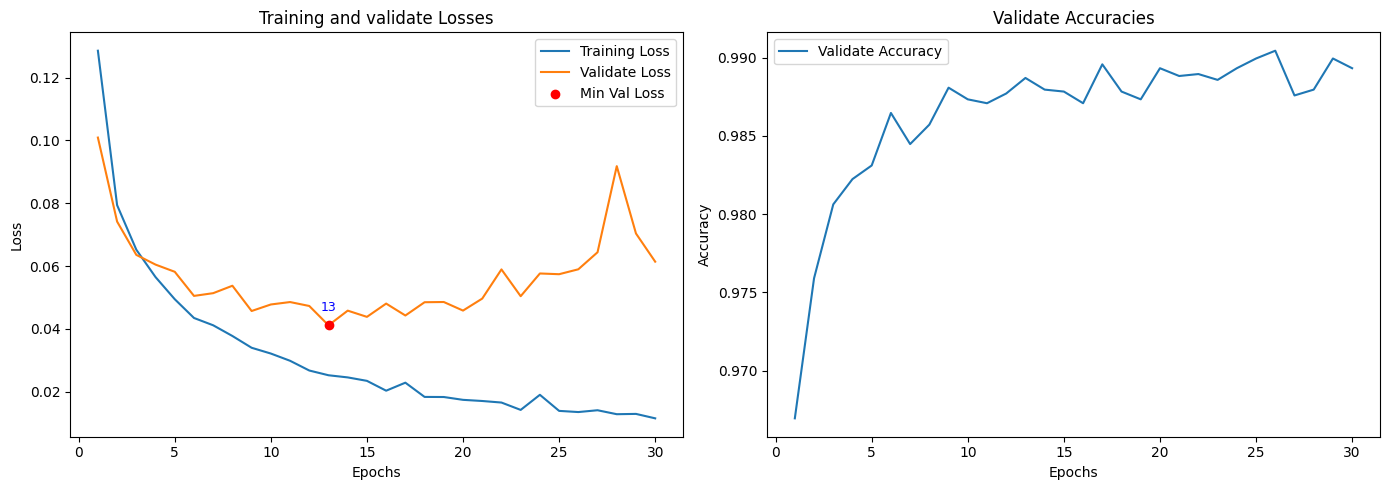

In [20]:
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, bert_epoch_num + 1), bert_train_losses, label='Training Loss')
plt.plot(range(1, bert_epoch_num + 1), bert_val_losses, label='Validate Loss')
plt.scatter(bert_best_epoch, bert_best_val_loss, color='red', label='Min Val Loss', zorder=5)
plt.annotate(f'{bert_best_epoch}',
             (bert_best_epoch, bert_best_val_loss),
             textcoords="offset points",
             xytext=(0,10),
             ha='center',
             color='blue',
             fontsize=9)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and validate Losses')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, bert_epoch_num + 1), bert_val_accuracies, label='Validate Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validate Accuracies')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
bert_spam_classifier_model.load_state_dict(bert_best_model_state)

print(f"Loaded best model from epoch {bert_best_epoch} with val loss {bert_best_val_loss:.4f}")



Loaded best model from epoch 13 with val loss 0.0411


In [22]:
bert_spam_classifier_model.eval()

bert_test_preds = []
bert_test_labels = []

with torch.no_grad():
    for inputs, labels in bert_test_loader:
        labels = labels.unsqueeze(1).float()
        outputs = bert_spam_classifier_model(inputs)
        predicted = (outputs > 0.5).float()

        bert_test_preds.extend(predicted.cpu().numpy())
        bert_test_labels.extend(labels.cpu().numpy())

bert_test_preds = np.array(bert_test_preds).flatten()
bert_test_labels = np.array(bert_test_labels).flatten()

In [23]:
bert_cm = confusion_matrix(bert_test_labels, bert_test_preds)
print("Confusion Matrix:")
print(bert_cm)

bert_test_accuracy  = accuracy_score(bert_test_labels, bert_test_preds)
bert_test_precision = precision_score(bert_test_labels, bert_test_preds)
bert_test_recall    = recall_score(bert_test_labels, bert_test_preds)
bert_test_f1        = f1_score(bert_test_labels, bert_test_preds)

print("Test Accuracy :", bert_test_accuracy)
print("Test Precision:", bert_test_precision)
print("Test Recall   :", bert_test_recall)
print("Test F1-score :", bert_test_f1)

Confusion Matrix:
[[3525   37]
 [  58 4431]]
Test Accuracy : 0.9882002235747113
Test Precision: 0.9917188898836168
Test Recall   : 0.9870795277344621
Test F1-score : 0.98939377023557


## 10.Model to compare(GPT-2)

### 10.1 Define SpamClassifierGPT2 class

In [25]:
class SpamClassifierGPT2(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=max_length)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx],dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

### 10.2 Setup models

In [26]:
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

gpt2_model = GPT2ForSequenceClassification.from_pretrained(
    "gpt2",
    num_labels = 2  # Binary classification
)
gpt2_model.config.pad_token_id = gpt2_tokenizer.pad_token_id

gpt2_epoch_num = 30

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 10.3 Setup datasets

In [27]:
# setup datasets

gpt2_train_dataset = SpamClassifierGPT2(X_train, y_train, gpt2_tokenizer)
gpt2_val_dataset   = SpamClassifierGPT2(X_val, y_val, gpt2_tokenizer)
gpt2_test_dataset  = SpamClassifierGPT2(X_test, y_test, gpt2_tokenizer)

### 10.4 define extra functions

In [28]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### 10.4 Training

In [29]:
training_args = TrainingArguments(
    output_dir = "./gpt2-spam",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_strategy = "epoch",
    per_device_train_batch_size = 64,
    per_device_eval_batch_size = 64,
    num_train_epochs = gpt2_epoch_num,
    weight_decay = 0.01,
    logging_dir = "./logs",
    load_best_model_at_end = True,
    metric_for_best_model="eval_loss",
    gradient_accumulation_steps = 2,
    report_to = "none",
    fp16 = True
)

gpt2_trainer = Trainer(
    model = gpt2_model,
    args = training_args,
    train_dataset = gpt2_train_dataset,
    eval_dataset = gpt2_val_dataset,
    processing_class = gpt2_tokenizer,
    compute_metrics = compute_metrics
)

gpt2_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.148100,0.049595,0.985716,0.990139,0.984184,0.987152
2,0.031600,0.036898,0.988821,0.990412,0.989530,0.989971
3,0.017400,0.031551,0.990684,0.988707,0.994654,0.991671
4,0.009300,0.038837,0.989442,0.989769,0.991312,0.990540
5,0.005800,0.041759,0.991057,0.992639,0.991312,0.991975
6,0.003900,0.046312,0.990809,0.992416,0.991089,0.991752
7,0.003400,0.057170,0.989318,0.992616,0.988193,0.990400
8,0.003200,0.116469,0.980375,0.994519,0.970149,0.982183
9,0.003000,0.061354,0.989691,0.992621,0.988862,0.990738
10,0.002500,0.055115,0.991802,0.991991,0.993317,0.992654


TrainOutput(global_step=8820, training_loss=0.00847261143244313, metrics={'train_runtime': 1878.5087, 'train_samples_per_second': 599.933, 'train_steps_per_second': 4.695, 'total_flos': 7.361905299554304e+16, 'train_loss': 0.00847261143244313, 'epoch': 30.0})

### 10.5. Plot Losses and Accuracies

In [30]:
gpt2_logs = gpt2_trainer.state.log_history

# Convert to DataFrame
gpt2_log_df = pd.DataFrame(gpt2_logs)
# Filter for loss and epoch info
gpt2_loss_df = gpt2_log_df[['epoch', 'loss', 'eval_loss','eval_accuracy']].dropna(how='all')

# Group by epoch and aggregate by 'first non-null'
gpt2_merged_df = gpt2_log_df.groupby('epoch').agg({
    'loss': 'first',
    'eval_loss': 'first',
    'eval_accuracy': 'first'
}).reset_index()

# Show merged result
print(gpt2_merged_df)

    epoch    loss  eval_loss  eval_accuracy
0     1.0  0.1481   0.049595       0.985716
1     2.0  0.0316   0.036898       0.988821
2     3.0  0.0174   0.031551       0.990684
3     4.0  0.0093   0.038837       0.989442
4     5.0  0.0058   0.041759       0.991057
5     6.0  0.0039   0.046312       0.990809
6     7.0  0.0034   0.057170       0.989318
7     8.0  0.0032   0.116469       0.980375
8     9.0  0.0030   0.061354       0.989691
9    10.0  0.0025   0.055115       0.991802
10   11.0  0.0024   0.097905       0.984722
11   12.0  0.0024   0.067021       0.991554
12   13.0  0.0019   0.064656       0.990809
13   14.0  0.0016   0.071269       0.990560
14   15.0  0.0020   0.090240       0.988200
15   16.0  0.0016   0.055435       0.991554
16   17.0  0.0014   0.059709       0.991926
17   18.0  0.0010   0.068933       0.991430
18   19.0  0.0010   0.078548       0.990063
19   20.0  0.0010   0.080103       0.988945
20   21.0  0.0009   0.062454       0.992423
21   22.0  0.0014   0.075878    

In [31]:
# Find the row with minimum eval_loss
gpt2_min_eval_loss_row = gpt2_merged_df.loc[gpt2_merged_df['eval_loss'].idxmin()]

gpt2_min_epoch = gpt2_min_eval_loss_row['epoch']
gpt2_min_eval_loss = gpt2_min_eval_loss_row['eval_loss']
gpt2_min_eval_accuracy = gpt2_min_eval_loss_row['eval_accuracy']

print(f"Epoch with minimum eval_loss: {gpt2_min_epoch}")
print(f"Minimum eval_loss: {gpt2_min_eval_loss}")


Epoch with minimum eval_loss: 3.0
Minimum eval_loss: 0.03155067190527916


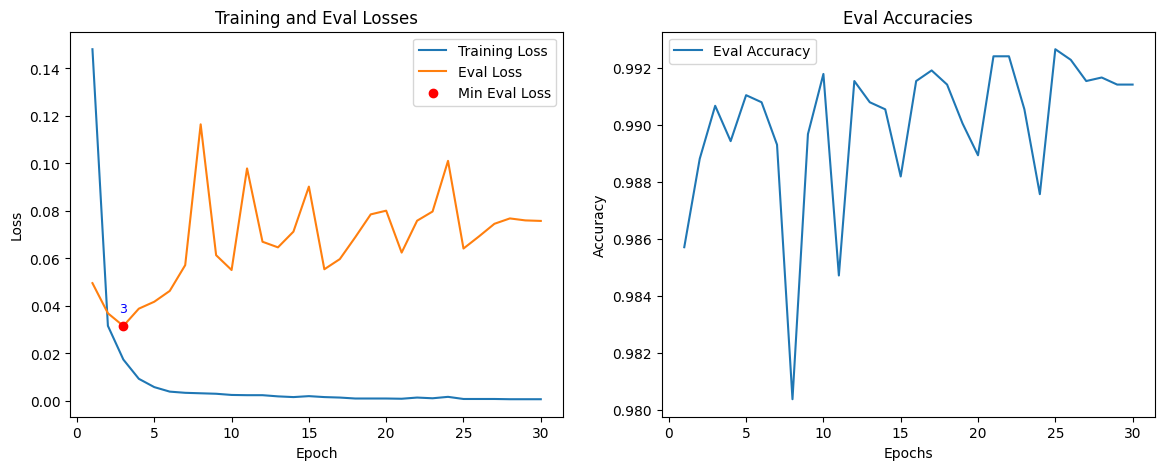

In [32]:
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, gpt2_epoch_num + 1), gpt2_merged_df['loss'], label='Training Loss')
plt.plot(range(1, gpt2_epoch_num + 1), gpt2_merged_df['eval_loss'], label='Eval Loss')
plt.scatter(gpt2_min_epoch, gpt2_min_eval_loss, color='red', label='Min Eval Loss', zorder=5)

plt.annotate(
    f'{int(gpt2_min_epoch)}',
    (gpt2_min_epoch, gpt2_min_eval_loss),
    textcoords="offset points",
    xytext=(0, 10),
    ha='center',
    color='blue',
    fontsize=9
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Eval Losses")
plt.legend()


# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, gpt2_epoch_num + 1), gpt2_merged_df['eval_accuracy'], label='Eval Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Eval Accuracies')
plt.legend()


plt.show()

In [33]:
# since we set  load_best_model_at_end = True and metric_for_best_model="eval_loss", so the default model is the best model we found

gpt2_test_metrics = gpt2_trainer.evaluate(gpt2_test_dataset)

print("Final TEST results (GPT-2):")
print(f"Accuracy : {gpt2_test_metrics['eval_accuracy']:.4f}")
print(f"Precision: {gpt2_test_metrics['eval_precision']:.4f}")
print(f"Recall   : {gpt2_test_metrics['eval_recall']:.4f}")
print(f"F1-score : {gpt2_test_metrics['eval_f1']:.4f}")



Final TEST results (GPT-2):
Accuracy : 0.9914
Precision: 0.9887
Recall   : 0.9960
F1-score : 0.9923


In [35]:
gpt2_test_output = gpt2_trainer.predict(gpt2_test_dataset)
# Logits -> predicted class
gpt2_test_logits = gpt2_test_output.predictions
gpt2_test_preds = np.argmax(gpt2_test_logits, axis=1)

# True labels
gpt2_test_labels = gpt2_test_output.label_ids

In [36]:
gpt2_cm = confusion_matrix(gpt2_test_labels, gpt2_test_preds)
print("Confusion Matrix:")
print(gpt2_cm)

gpt2_test_accuracy  = accuracy_score(gpt2_test_labels, gpt2_test_preds)
gpt2_test_precision = precision_score(gpt2_test_labels, gpt2_test_preds)
gpt2_test_recall    = recall_score(gpt2_test_labels, gpt2_test_preds)
gpt2_test_f1        = f1_score(gpt2_test_labels, gpt2_test_preds)

print("Test Accuracy :", gpt2_test_accuracy)
print("Test Precision:", gpt2_test_precision)
print("Test Recall   :", gpt2_test_recall)
print("Test F1-score :", gpt2_test_f1)


Confusion Matrix:
[[3511   51]
 [  18 4471]]
Test Accuracy : 0.9914296360700534
Test Precision: 0.9887218045112782
Test Recall   : 0.9959901982624193
Test F1-score : 0.9923426922650095
